In [1]:
import torch
from torch import nn
import pandas as pd
import sys
from pathlib import Path

train_labels = pd.read_csv('../cifar-10/trainLabels.csv')
val_labels = pd.read_csv('../cifar-10/valLabels.csv')

sys.path.append(str(Path.cwd().parent))
torch.manual_seed(42)

In [2]:
from src.dataset import CIFAR10Dataset, train_transforms, val_transforms

train_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/train',
    labels=train_labels,
    transform=train_transforms
)

val_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/val',
    labels=val_labels,
    transform=val_transforms
)

In [3]:
from src.dataset import create_dataloader

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## Weight Decay

In [5]:
from src.models import CIFARBaseline
from src.metrics import create_metrics
from src.engine import fit

exp1 = CIFARBaseline().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=exp1.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
epochs = 30

history = fit(
    model=exp1,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Augmentation_WD.pt'
)

history


Epoch 1/30:
Training Loss: 1.6977 | Training Accuracy: 36.84% | Training Precision: 36.13% | Training Recall: 36.84%
Validation Loss: 1.3680 | Validation Accuracy: 49.48% | Validation Precision: 52.23% | Validation Recall: 49.48%
Best model saved! Val Acc: 49.48%

Epoch 2/30:
Training Loss: 1.2725 | Training Accuracy: 53.67% | Training Precision: 53.06% | Training Recall: 53.67%
Validation Loss: 1.0092 | Validation Accuracy: 64.50% | Validation Precision: 65.04% | Validation Recall: 64.50%
Best model saved! Val Acc: 64.50%

Epoch 3/30:
Training Loss: 1.0608 | Training Accuracy: 62.03% | Training Precision: 61.68% | Training Recall: 62.03%
Validation Loss: 0.9008 | Validation Accuracy: 67.68% | Validation Precision: 69.02% | Validation Recall: 67.68%
Best model saved! Val Acc: 67.68%

Epoch 4/30:
Training Loss: 0.9581 | Training Accuracy: 65.81% | Training Precision: 65.52% | Training Recall: 65.81%
Validation Loss: 0.8797 | Validation Accuracy: 68.12% | Validation Precision: 70.15% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.697697,0.368425,0.361317,0.368425,1.367981,0.4948,0.522252,0.4948
1,2,1.272518,0.536700,0.530642,0.536700,1.009227,0.6450,0.650440,0.6450
2,3,1.060819,0.620300,0.616762,0.620300,0.900773,0.6768,0.690228,0.6768
3,4,0.958142,0.658050,0.655231,0.658050,0.879689,0.6812,0.701485,0.6812
4,5,0.877090,0.688975,0.686937,0.688975,0.767186,0.7332,0.736033,0.7332
5,6,0.829509,0.708200,0.706312,0.708200,0.734392,0.7386,0.743071,0.7386
6,7,0.791779,0.721300,0.719782,0.721300,0.717363,0.7464,0.753851,0.7464
7,8,0.756123,0.732500,0.731022,0.732500,0.691013,0.7594,0.765065,0.7594
8,9,0.726475,0.745750,0.744566,0.745750,0.667411,0.7652,0.771620,0.7652
9,10,0.699893,0.754550,0.753486,0.754550,0.646039,0.7738,0.780247,0.7738


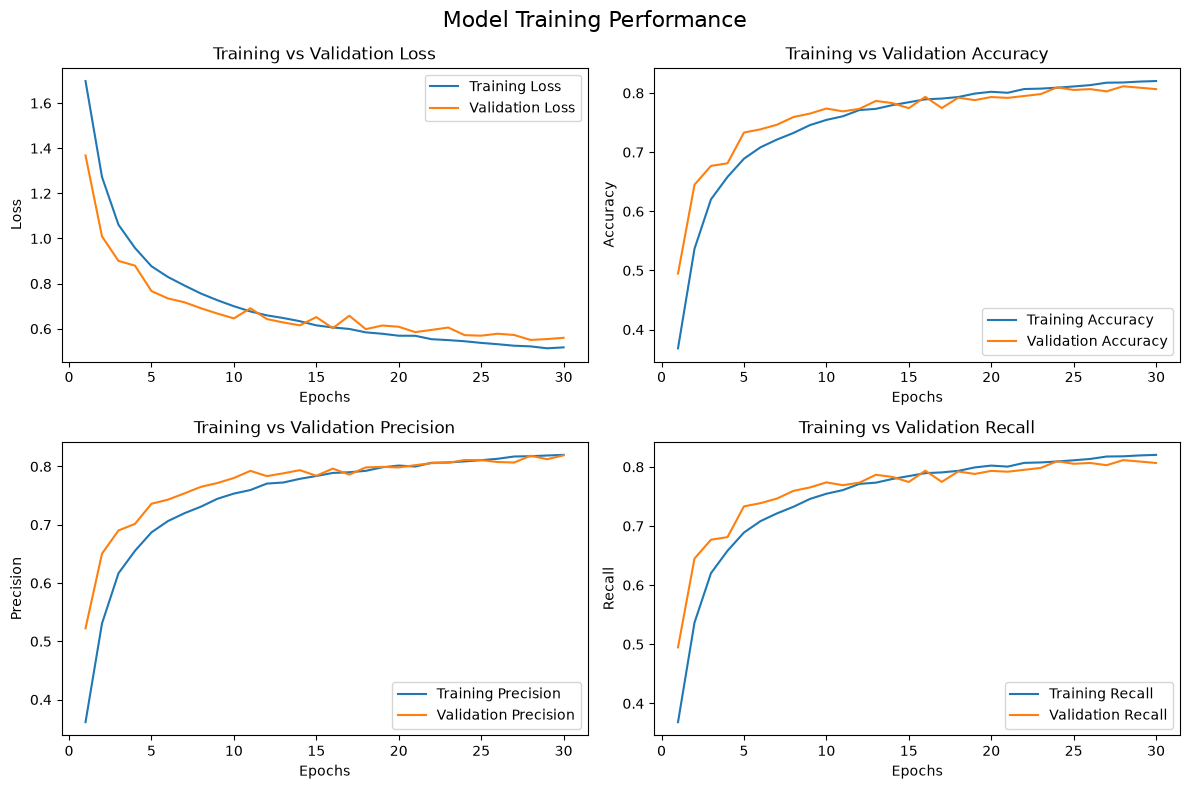

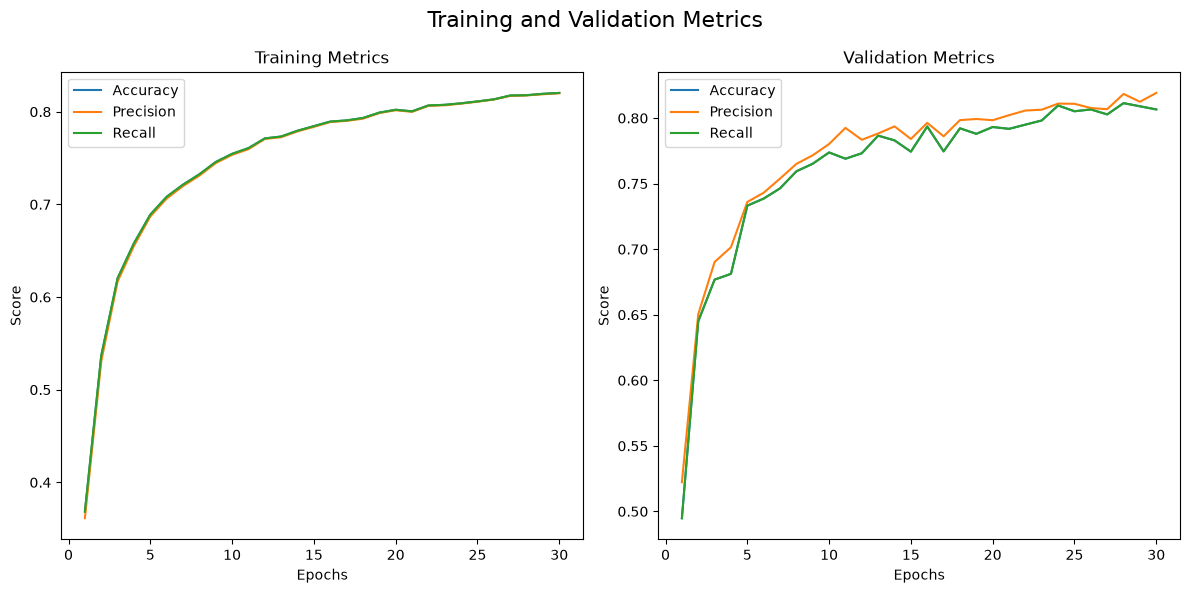

In [6]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)

## Dropout

In [7]:
from src.models import CIFARDropout
from src.metrics import create_metrics
from src.engine import fit

exp2 = CIFARDropout().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=exp2.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
epochs = 30

history = fit(
    model=exp2,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Augmentation_WD_Dropout.pt'
)

history


Epoch 1/30:
Training Loss: 1.7709 | Training Accuracy: 34.33% | Training Precision: 33.48% | Training Recall: 34.33%
Validation Loss: 1.4116 | Validation Accuracy: 47.80% | Validation Precision: 49.56% | Validation Recall: 47.80%
Best model saved! Val Acc: 47.80%

Epoch 2/30:
Training Loss: 1.4307 | Training Accuracy: 47.71% | Training Precision: 46.81% | Training Recall: 47.71%
Validation Loss: 1.2055 | Validation Accuracy: 55.42% | Validation Precision: 56.93% | Validation Recall: 55.42%
Best model saved! Val Acc: 55.42%

Epoch 3/30:
Training Loss: 1.2464 | Training Accuracy: 55.00% | Training Precision: 54.47% | Training Recall: 55.00%
Validation Loss: 1.0208 | Validation Accuracy: 63.76% | Validation Precision: 63.74% | Validation Recall: 63.76%
Best model saved! Val Acc: 63.76%

Epoch 4/30:
Training Loss: 1.1156 | Training Accuracy: 59.98% | Training Precision: 59.61% | Training Recall: 59.98%
Validation Loss: 0.9415 | Validation Accuracy: 66.52% | Validation Precision: 68.15% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.770863,0.343325,0.334788,0.343325,1.411582,0.4780,0.495641,0.4780
1,2,1.430701,0.477100,0.468115,0.477100,1.205492,0.5542,0.569298,0.5542
2,3,1.246359,0.550000,0.544718,0.550000,1.020809,0.6376,0.637415,0.6376
3,4,1.115557,0.599775,0.596061,0.599775,0.941453,0.6652,0.681469,0.6652
4,5,1.043879,0.628850,0.626279,0.628850,0.892038,0.6914,0.715050,0.6914
5,6,0.982673,0.653550,0.651084,0.653550,0.820266,0.7098,0.712455,0.7098
6,7,0.949735,0.663600,0.661224,0.663600,0.853508,0.7036,0.710308,0.7036
7,8,0.916502,0.678575,0.676070,0.678575,0.761033,0.7288,0.735944,0.7288
8,9,0.884871,0.686800,0.684583,0.686800,0.740504,0.7340,0.740591,0.7340
9,10,0.856305,0.697725,0.695745,0.697725,0.722009,0.7398,0.747824,0.7398


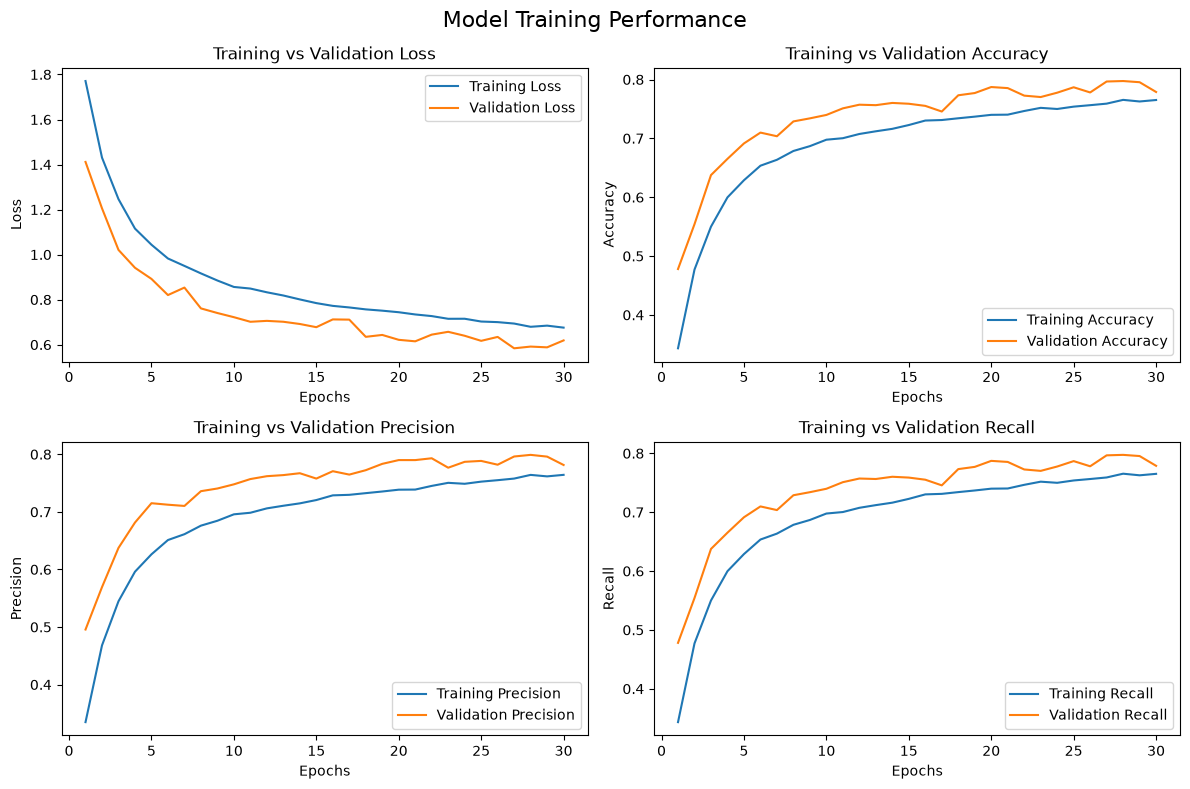

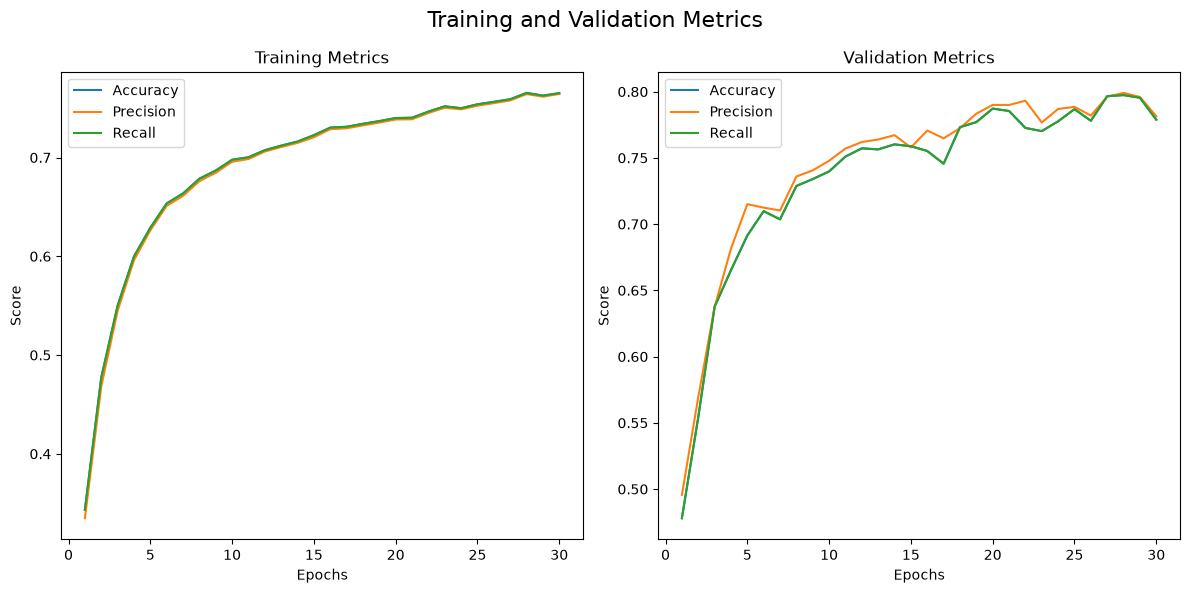

In [8]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)